In [16]:
# conda create -n test_Phot python=3.11 -y
# conda activate test_Phot
# pip install astropy photutils numpy matplotlib ipykernel astroquery

Background: mean=3001.75, median=3000.00, std=125.18
Total detections: 13
    x_centroid         y_centroid        flux    source_type  
------------------ ------------------ --------- --------------
417.66149837060766   417.815744252089 2864258.0 saturated_blob
 233.4236034195387 469.92874885746545   92995.0 saturated_blob
 65.36274015458413  299.1066833299573   23481.0          point
 32.63824161601262   542.514957393698   19022.0          point
154.43184879902185 322.57646226431024   18827.0          point
433.44707016072334 260.06883537789145   16239.0          point
411.53459789763156  469.0023927610304   12464.0          point
156.64987549968754  832.7871376975944   11202.0          point
 204.0580130590585  688.7504919893663    9432.0          point
 567.7878920619394  635.0720345281532    8704.0          point
140.14169167115705 495.56232003980944    8003.0          point
 522.7660841857506 250.30137767272055    7807.0          point
 734.0540242872711  536.9793826512987    612

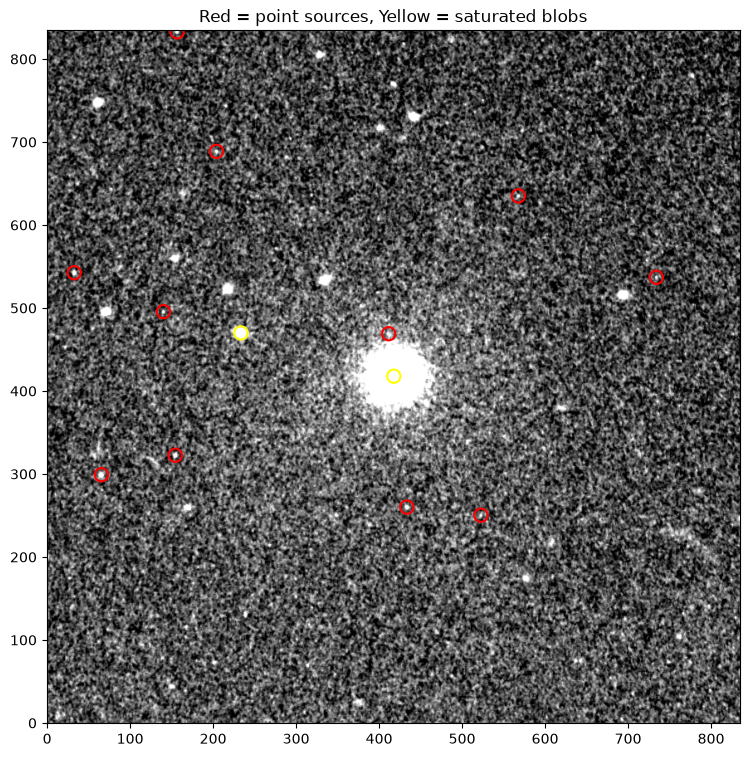


Brightest point-source detections:
    x_centroid         y_centroid       flux  source_type
------------------ ------------------ ------- -----------
 65.36274015458413  299.1066833299573 23481.0       point
 32.63824161601262   542.514957393698 19022.0       point
154.43184879902185 322.57646226431024 18827.0       point
433.44707016072334 260.06883537789145 16239.0       point
411.53459789763156  469.0023927610304 12464.0       point
156.64987549968754  832.7871376975944 11202.0       point
 204.0580130590585  688.7504919893663  9432.0       point
 567.7878920619394  635.0720345281532  8704.0       point
140.14169167115705 495.56232003980944  8003.0       point
 522.7660841857506 250.30137767272055  7807.0       point
 734.0540242872711  536.9793826512987  6124.0       point

Fitting FWHM for the top few point sources...

Fitting star at (65.4, 299.1), flux=23481.0


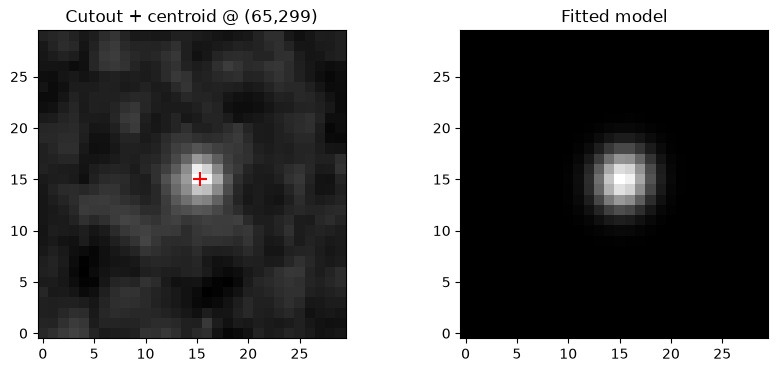

  FWHM_x = 4.17 px, FWHM_y = 4.58 px

Fitting star at (32.6, 542.5), flux=19022.0


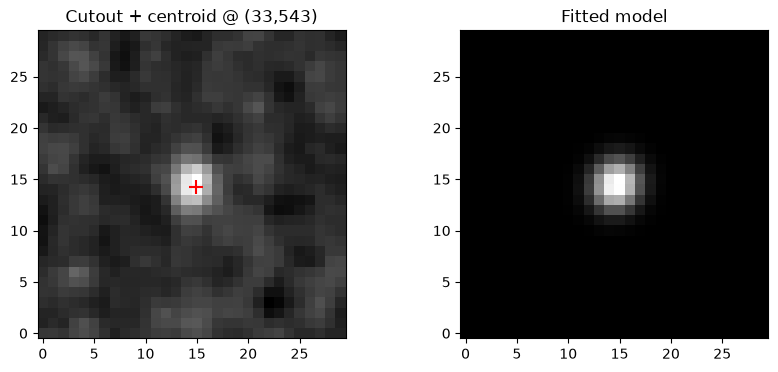

WARNING

  FWHM_x = 3.58 px, FWHM_y = 3.90 px

Fitting star at (154.4, 322.6), flux=18827.0


: The fit may not have converged. Please check your results. [photutils.centroids.gaussian]


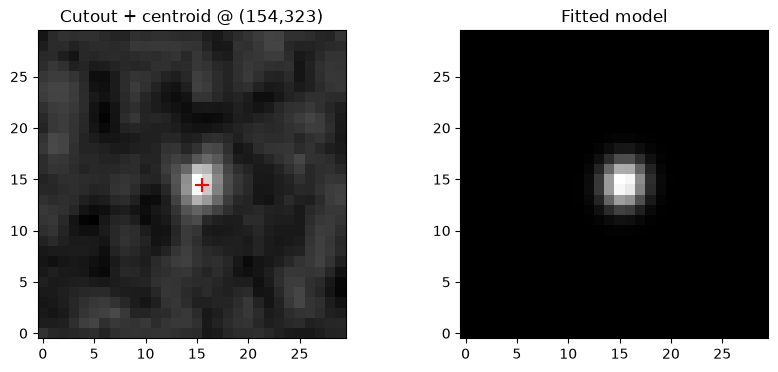

  FWHM_x = 3.22 px, FWHM_y = 3.65 px

Fitting star at (433.4, 260.1), flux=16239.0


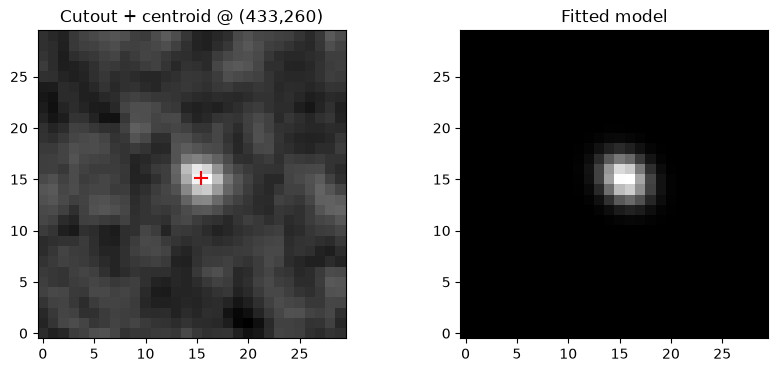

  FWHM_x = 3.88 px, FWHM_y = 3.25 px

Fitting star at (411.5, 469.0), flux=12464.0


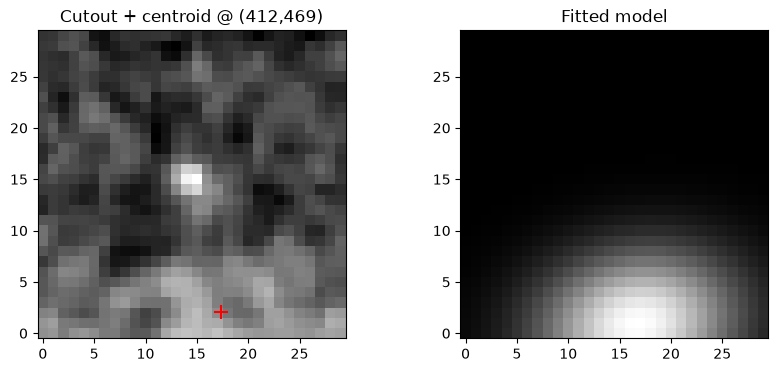

  FWHM_x = 11.24 px, FWHM_y = 15.57 px


In [23]:
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle

from astropy.io import fits
from astropy.wcs import WCS
from astropy.stats import sigma_clipped_stats
from astropy.table import Table
from astropy.modeling import models, fitting

from photutils.detection import DAOStarFinder
from photutils.segmentation import detect_sources, SourceCatalog
from photutils.centroids import centroid_2dg

# --- CONFIG ---
DATA_DIR = r"C:\Users\dapur\Downloads\Other\Research\rcb_Star_Dust_Survey\test_CNN\data\R_CrB\cutouts"
FWHM = 3.0
THRESHOLD_SIGMA = 5.0
SATURATION_LEVEL = None


def get_wcs_and_data(filepath):
    with fits.open(filepath) as hdul:
        for hdu in hdul:
            if hdu.data is not None:
                data = hdu.data.astype(float)
                header = hdu.header
                try:
                    wcs = WCS(header)
                    if not wcs.has_celestial:
                        wcs = None
                except Exception:
                    wcs = None
                return data, header, wcs
    return None, None, None


def _get_col(table, *candidates):
    for name in candidates:
        if name in table.colnames:
            return name
    raise KeyError(f"None of {candidates} found in columns: {table.colnames}")


def detect_saturated_blobs(data, median, std, min_area=15):
    sat_level = SATURATION_LEVEL if SATURATION_LEVEL is not None else np.percentile(data, 99.9)
    threshold = max(sat_level, median + 15 * std)

    segm = detect_sources(data, threshold=threshold, n_pixels=min_area)
    if segm is None:
        return None

    cat = SourceCatalog(data - median, segm)
    tbl = cat.to_table()
    tbl = tbl[tbl["area"].value >= min_area]
    return tbl


def detect_stars_robust(data, median, std):
    daofind = DAOStarFinder(
        fwhm=FWHM,
        threshold=THRESHOLD_SIGMA * std,
        sharpness_range=(0.2, 1.0),
        roundness_range=(-1.0, 1.0),
    )
    point_sources = daofind(data - median)
    blobs = detect_saturated_blobs(data, median, std)

    records = []

    if point_sources is not None and len(point_sources) > 0:
        xcol = _get_col(point_sources, "x_centroid", "xcentroid")
        ycol = _get_col(point_sources, "y_centroid", "ycentroid")
        for row in point_sources:
            records.append((row[xcol], row[ycol], row["flux"], "point"))

    if blobs is not None and len(blobs) > 0:
        bxcol = _get_col(blobs, "x_centroid", "xcentroid")
        bycol = _get_col(blobs, "y_centroid", "ycentroid")
        fluxcol = _get_col(blobs, "segment_flux", "flux", "source_sum")

        for row in blobs:
            x, y = row[bxcol], row[bycol]
            if point_sources is not None and len(point_sources) > 0:
                dists = np.hypot(point_sources[xcol] - x, point_sources[ycol] - y)
                if dists.min() < 5:
                    continue
            records.append((x, y, row[fluxcol], "saturated_blob"))

    if not records:
        return None

    merged = Table(rows=records, names=("x_centroid", "y_centroid", "flux", "source_type"))
    merged.sort("flux", reverse=True)
    return merged


def measure_fwhm_2d(data, x0_guess, y0_guess, box=15):
    x0_guess, y0_guess = int(round(x0_guess)), int(round(y0_guess))
    cutout = data[y0_guess-box:y0_guess+box, x0_guess-box:x0_guess+box]

    cx, cy = centroid_2dg(cutout - np.median(cutout))

    yy, xx = np.indices(cutout.shape)

    g_init = models.Gaussian2D(
        amplitude=cutout.max() - np.median(cutout),
        x_mean=cx, y_mean=cy,
        x_stddev=2.0, y_stddev=2.0,
    ) + models.Const2D(np.median(cutout))

    fitter = fitting.LevMarLSQFitter()
    g_fit = fitter(g_init, xx, yy, cutout)

    sigma_x = g_fit.x_stddev_0.value
    sigma_y = g_fit.y_stddev_0.value
    fwhm_x = 2.355 * sigma_x
    fwhm_y = 2.355 * sigma_y

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    axes[0].imshow(cutout, cmap="gray", origin="lower")
    axes[0].scatter([cx], [cy], color="red", marker="+", s=100)
    axes[0].set_title(f"Cutout + centroid @ ({x0_guess},{y0_guess})")

    axes[1].imshow(g_fit(xx, yy), cmap="gray", origin="lower")
    axes[1].set_title("Fitted model")
    plt.show()

    return fwhm_x, fwhm_y, g_fit


# --- RUN DETECTION ---
filepath = os.path.join(DATA_DIR, "00460_i28786m0s0.fits")
data, header, wcs = get_wcs_and_data(filepath)
data = np.nan_to_num(data, nan=np.nanmedian(data))

mean, median, std = sigma_clipped_stats(data, sigma=3.0)
print(f"Background: mean={mean:.2f}, median={median:.2f}, std={std:.2f}")

sources = detect_stars_robust(data, median, std)
print(f"Total detections: {len(sources)}")
print(sources)

# --- OVERVIEW PLOT ---
fig, ax = plt.subplots(figsize=(9, 9))
vmin, vmax = np.percentile(data, [5, 99])
ax.imshow(data, cmap="gray", origin="lower", vmin=vmin, vmax=vmax)
for row in sources:
    color = "red" if row["source_type"] == "point" else "yellow"
    ax.add_patch(Circle((row["x_centroid"], row["y_centroid"]), radius=8,
                         edgecolor=color, facecolor="none", linewidth=1.5))
ax.set_title("Red = point sources, Yellow = saturated blobs")
plt.show()

# --- FWHM MEASUREMENT ON BRIGHTEST DETECTED POINT SOURCES ---
point_only = sources[sources["source_type"] == "point"]
point_only.sort("flux", reverse=True)
print("\nBrightest point-source detections:")
print(point_only)

print("\nFitting FWHM for the top few point sources...")
for row in point_only[:5]:
    x, y = row["x_centroid"], row["y_centroid"]
    print(f"\nFitting star at ({x:.1f}, {y:.1f}), flux={row['flux']:.1f}")
    try:
        fwhm_x, fwhm_y, fit = measure_fwhm_2d(data, x, y)
        print(f"  FWHM_x = {fwhm_x:.2f} px, FWHM_y = {fwhm_y:.2f} px")
    except Exception as e:
        print(f"  Fit failed: {e}")